<a href="https://colab.research.google.com/github/ken14121/-_loadto-/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E8%A7%A3%E6%9E%901_0601.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**復習**

1.   ・リストの作り方
2.   ・データフレームの作り方
1.   ・データフレームの細かい扱い方

In [1]:
import pandas as pd

data = {
    "日付":["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "天気":["晴れ", "曇り", "雨", "晴れ", "晴れ"],
    "大人":[1200, 950, 420, 1500, 1650],
    "子供":[450, 320, 110, 850, 980],
    "高校生":[300, 280, 90, 400, 420],
    "カップル":[600, 500, 210, 750, 800],
    "一人":[80, 95, 45, 70, 65]
}

#2.Pdのデータフレームに変換
df = pd.DataFrame(data)

# 3. 作成したデータ（表）の先頭を表示
df

,日付,天気,大人,子供,高校生,カップル,一人
0,2026-05-01,晴れ,1200,450,300,600,80
1,2026-05-02,曇り,950,320,280,500,95
2,2026-05-03,雨,420,110,90,210,45
3,2026-05-04,晴れ,1500,850,400,750,70
4,2026-05-05,晴れ,1650,980,420,800,65


In [3]:
df.head(3)

,日付,天気,大人,子供,高校生,カップル,一人
0,2026-05-01,晴れ,1200,450,300,600,80
1,2026-05-02,曇り,950,320,280,500,95
2,2026-05-03,雨,420,110,90,210,45


In [2]:
df.iloc[0:3, 0:3]

,日付,天気,大人
0,2026-05-01,晴れ,1200
1,2026-05-02,曇り,950
2,2026-05-03,雨,420


**今日は**

1.   リストからグラフ作成
2.   グラフの分析
1.   分析による予測


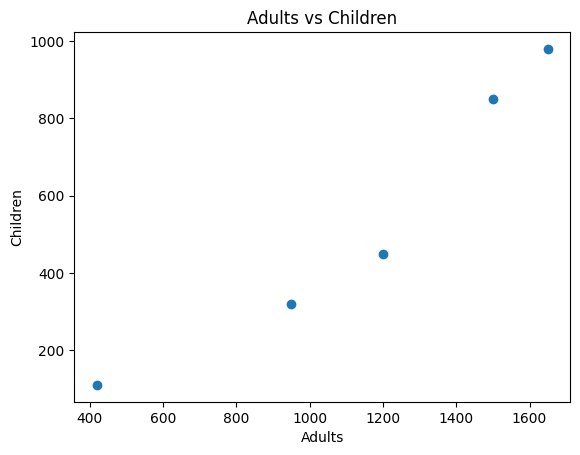

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "日付": ["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "天気": ["晴れ", "曇り", "雨", "晴れ", "晴れ"],
    "大人": [1200, 950, 420, 1500, 1650],
    "子供": [450, 320, 110, 850, 980]
}
df = pd.DataFrame(data)

#1.グラフの描画設定（散布図scatter）Pythonでグラフを描くMatplotlib
plt.scatter(df["大人"], df["子供"])

#2.グラフのタイトルや軸の名前を設定
plt.title("Adults vs Children")
plt.xlabel("Adults")
plt.ylabel("Children")

#3.グラフを画面に表示
plt.show()

**なぜ plt.show() が必要なのか？(printfではダメな理由)**

1.   グラフを描く処理(plt.scatter)などを行っているとき、Pythonは画面に見えないメモリ上の裏舞台(バッファ)で、「点の座標」や「軸の線」を計算して1枚の画像(グラフのオブジェクト)を組み立てている。

2.   この組み立てられた画像は、ただの数値の塊であり、文字ではないため printでは扱えない。
そこで登場するのが plt.show() で、この関数を呼び出すことで、初めて以下の巨大な処理が裏側で実行される。

1.   メモリ上で組み立て中だったグラフの描画処理を完全にストップさせて固定する。Google ColabやOSに対して「今作った画像データを、人間が見えるウインドウとしてレンダリングして割り込ませろ」と命令を出す。

2.   C言語でいうと、単なる printf ではなく、「グラフィックス用の外部ライブラリ(OpenGLやDXLibなど)を呼び出して、描画バッファを画面にフリップ（反映）させる関数を実行した」という状態に近い。


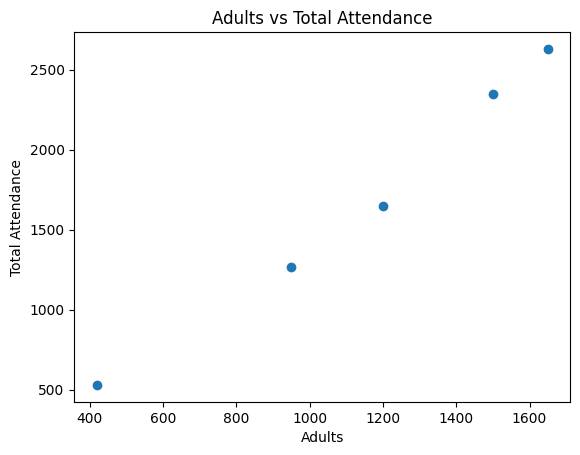

In [5]:
df["総客数"] = df["大人"] + df["子供"]

#「大人」と「総客数」の散布図
plt.scatter(df["大人"], df["総客数"])

plt.title("Adults vs Total Attendance")
plt.xlabel("Adults")
plt.ylabel("Total Attendance")
plt.show()

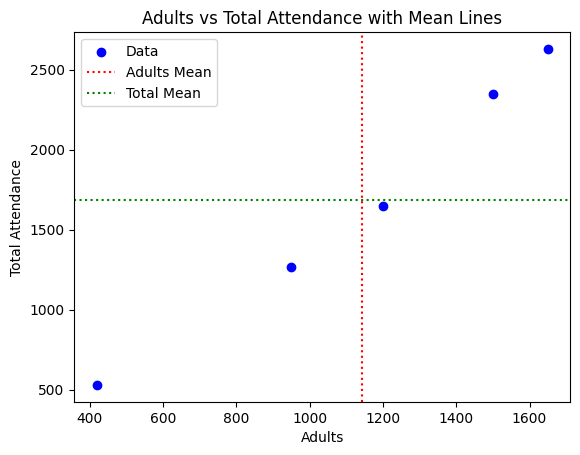

In [14]:
plt.scatter(df["大人"], df["総客数"], color="blue", label="Data")
#関数
#(a)大人の平均値に、縦の赤線を引く
plt.axvline(x=df["大人"].mean(), color="red", linestyle=":", label="Adults Mean")

#(b)総客数の平均値に、横の緑線を引く
plt.axhline(y=df["総客数"].mean(), color="green", linestyle=":", label="Total Mean")

#グラフの装飾と表示
plt.title("Adults vs Total Attendance with Mean Lines")
plt.xlabel("Adults")
plt.ylabel("Total Attendance")
plt.legend() # 線の説明を表示
plt.show()

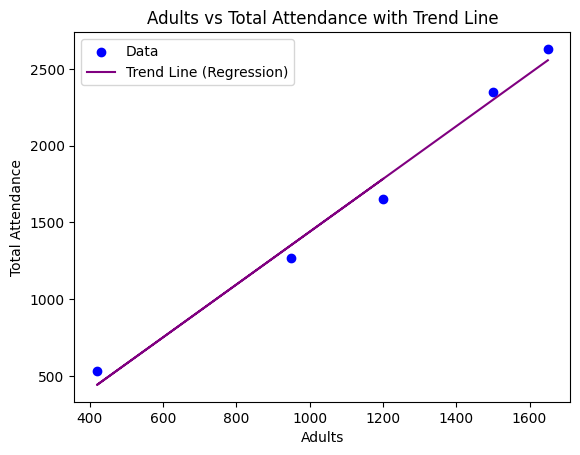

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  #数値計算用のライブラリ

#1.データ準備
data = {
    "日付": ["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "大人": [1200, 950, 420, 1500, 1650],
    "子供": [450, 320, 110, 850, 980]
}
df = pd.DataFrame(data)
df["総客数"] = df["大人"] + df["子供"]

#2.散布図を描画
plt.scatter(df["大人"], df["総客数"], color="blue", label="Data")

#3.関数で斜めの線を出す
#直線の「傾き」と「切片」を自動計算(polyfit関数)
a, b = np.polyfit(df["大人"], df["総客数"], 1)

# 計算した傾きaと切片bを使って、斜めの直線を引く
# y = a * x + b の直線の式をそのままグラフに描画する
x_line = df["大人"]
y_line = a * x_line + b #計算結果をそのまま入れてる
plt.plot(x_line, y_line, color="purple", label="Trend Line (Regression)")

# 4. グラフの表示
plt.title("Adults vs Total Attendance with Trend Line")
plt.xlabel("Adults")
plt.ylabel("Total Attendance")
plt.legend()
plt.show()

In [12]:
import pandas as pd
import numpy as np

data = {
    "日付": ["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "大人": [1200, 950, 420, 1500, 1650],
    "子供": [450, 320, 110, 850, 980]
}
df = pd.DataFrame(data)
df["総客数"] = df["大人"] + df["子供"]

# #直線の「傾き」と「切片」を自動計算(polyfit関数)
a, b = np.polyfit(df["大人"], df["総客数"], 1)

#計算された数式を画面に表示
print(f"総客数 = {a:.2f} × 大人数 + {b:.2f}")
print("-" * 30)

#未来の予測大人が1400人来た場合の総客数を計算
future_adults = 1400
predicted_total = a * future_adults + b

print(f"【未来の需要予測結果】")
print(f"もし明日、大人が {future_adults} 人来場する場合、")
print(f"予測される総客数は【 {int(predicted_total)} 人 】である。")

【算出した予測の数式】
総客数 = 1.72 × 大人数 + -281.20
------------------------------
【未来の需要予測結果】
もし明日、大人が 1400 人来場する場合、
予測される総客数は【 2126 人 】である。


print(f"総客数 = {a:.2f} × 大人数 + {b:.2f}")
print("-" * 30)なんでこれで動くのか

ダブルクォーテーションの直前についているfという文字にこたえがある

Pythonの処理系は、文字列の前にfがついているのを見つけると、「あ、この文字列の中にはプログラムの命令が隠されているな」と判断し、特殊な解析モードに入る。

{a:.2f}の発見
Pythonは {} を見つけると、その中身を文字ではなく「Pythonの変数や命令」として実行する。今回の場合、変数 a の中身(1.72...)を引っこ抜いてくる。

:.2f という命令の実行
コロン : の後ろは、C言語の %.2f と全く同じ「書式設定の命令」である。Pythonは「今持ってきた変数 a の数値を、小数点以下2桁の文字列に変換せよ」という命令をその場で実行する。

文字列への合体
変換された「"1.72"」という文字が、元の {a:.2f} があった場所に埋め込まれる。

つまり、人間が書いているときはただの文字列に見えるが、Pythonが実行する瞬間に、内部で {} の中身を1つずつ計算・変換して普通の文字列に書き換える処理が自動で行われている。

In [16]:
# #関数まとめ

# #2.Pdのデータフレームに変換
# df = pd.DataFrame(data)

# #1.グラフの描画設定（散布図scatter）Pythonでグラフを描くMatplotlib
# plt.scatter(df["大人"], df["子供"])

# #直線の「傾き」と「切片」を自動計算(polyfit関数)
# a, b = np.polyfit(df["大人"], df["総客数"], 1)

# plt.title("Adults vs Total Attendance with Mean Lines")
# plt.xlabel("Adults")
# plt.ylabel("Total Attendance")
# plt.legend() # 線の説明を表示
# plt.show()